In the name of God
### Question 4


##### 4-1 Intro
In the following notebook we are going to develop an autoencoder, to reduce the dimension of our dataset, and then use the encoder part with simple dense MLP network to classify the data.
The dataset used is the MNIST dataset which can be accessed using TensorFlow (tf.keras.datasets.mnist) but since I already had the file I used that
 

##### 4-2 Loading the dataset and preprocessing

__Loading the dataset__

In [1]:
import numpy as np
import tensorflow as tf

with np.load("mnist.npz") as data:
    x_train, y_train = data["x_train"], data["y_train"]
    x_test, y_test = data["x_test"], data["y_test"]

print(f"x_train.shape = {x_train.shape}")
print(f"x_train.shape = {y_train.shape}")

2025-03-19 22:04:31.548488: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-19 22:04:31.556664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742409271.566020   66223 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742409271.568805   66223 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742409271.576150   66223 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

x_train.shape = (60000, 28, 28)
x_train.shape = (60000,)


__Flattening the data__ since each data is a 28*28 matrix, in order to use it in our network we shall flatten it to a 784-dimensional vector 

In [2]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(f"x_train.shape = {x_train.shape}")
print(f"x_test.shape = {x_test.shape}")

x_train[32].max()

x_train.shape = (60000, 784)
x_test.shape = (10000, 784)


np.uint8(255)

__Normalising the data__ in order to avoid bias in our network due to the size of the input, we need to normalise the data in the [0, 1] range

In [3]:
x_train = x_train.astype("float64") / 255.0
x_test = x_test.astype("float64") / 255.0

x_test[32].max()

np.float64(0.996078431372549)

#### 4-3 Designing and Implementing the models

##### 4-3-1 Designing and Training the auto encoders
For this section we are going to implement two autoencoders, each representing a latent space with a different size.

**Model One:** Autoencoder with 8 output neurons in the encoder  
  - **Architecture** (the number of neurons and activation function in each layer):  
    - Encoder: 784, 128 (ReLU), 8 (ReLU).  
    - Decoder: 8, 128 (ReLU), 784 (Linear).  
  - **Training Settings:**  
    - Loss Function: MSE.  
    - Number of Training Epochs: At least 20.  

**Model Two:**  
  - **Architecture:**  
    - Encoder: 784, 128 (ReLU), 4 (ReLU).  
    - Decoder: 4, 128 (ReLU), 784 (Linear).  
  - **Training Settings:** Similar to Model One.  

In order to simplify the code, a function has been defined to create the model based on the size of the latened space (This was possible due to the fact that both models had 3 layers for their encoder/decoder and only the size of the last/first layer was variable)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_autoencoder(latent_space_dimension):
    # Encoder
    encoder_input = keras.Input(
        shape=(784,)
    )
    
    middle_layer = layers.Dense(
        128, 
        activation="relu"
    )(encoder_input)
    
    latent_output = layers.Dense(
        latent_space_dimension, 
        activation="relu"
    )(middle_layer)

    # Decoder
    middle_layer = layers.Dense(
        128, 
        activation="relu"
    )(latent_output)
    decoder_output = layers.Dense(
        784, 
        activation="linear"
    )(middle_layer)
    autoencoder = keras.Model(
        encoder_input, 
        decoder_output, 
        name=f"Autoencoder_{latent_space_dimension}"
    )

    return autoencoder

Now that we can build the models, we call the functions, build our models and train them!

MSE has been chosen as the loss function and we employed adam as the optimizer

In [5]:
autoencoder_latent_space_8 = build_autoencoder(
    latent_space_dimension=8
)
autoencoder_latent_space_4 = build_autoencoder(
    latent_space_dimension=4
)

autoencoder_latent_space_8.compile(
    optimizer="adam", 
    loss="mse"
)
autoencoder_latent_space_4.compile(
    optimizer="adam", 
    loss="mse"
)

autoencoder_latent_space_8_history = autoencoder_latent_space_8.fit(
    x_train, 
    x_train, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, x_test)
)
autoencoder_latent_space_4_history = autoencoder_latent_space_4.fit(
    x_train, 
    x_train, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, x_test)
)

I0000 00:00:1742409273.242578   66223 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 862 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/40


I0000 00:00:1742409274.393278   66303 service.cc:152] XLA service 0x7bcd78003b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742409274.393290   66303 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-03-19 22:04:34.409816: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742409274.492417   66303 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-03-19 22:04:35.125495: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_194', 4 bytes spill stores, 4 bytes spill loads

2025-03-19 22:04:35.417780: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_d

 196/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - loss: 0.0667

I0000 00:00:1742409277.127033   66303 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0425 - val_loss: 0.0306
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 913us/step - loss: 0.0299 - val_loss: 0.0275
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 910us/step - loss: 0.0275 - val_loss: 0.0265
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 909us/step - loss: 0.0266 - val_loss: 0.0260
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 923us/step - loss: 0.0262 - val_loss: 0.0257
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 911us/step - loss: 0.0258 - val_loss: 0.0255
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 903us/step - loss: 0.0255 - val_loss: 0.0252
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 918us/step - loss: 0.0254 - val_loss: 0.0251
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 914us/step - loss: 0.0251 - val_loss: 0.0249
Epoch 10/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 912us/step - loss: 0.0250 - val_loss: 0.0248
Epoch 11/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 899us/step - loss: 0.0250 - val_loss: 0.0247
Epoch 12/40
1875/1875

2025-03-19 22:05:51.725995: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_194', 4 bytes spill stores, 4 bytes spill loads



1856/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - loss: 0.0620

2025-03-19 22:05:54.718299: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24', 12 bytes spill stores, 12 bytes spill loads



1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0619 - val_loss: 0.0429
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 955us/step - loss: 0.0419 - val_loss: 0.0397
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0378 - val_loss: 0.0349
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 980us/step - loss: 0.0348 - val_loss: 0.0340
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 966us/step - loss: 0.0340 - val_loss: 0.0334
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 978us/step - loss: 0.0334 - val_loss: 0.0332
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 985us/step - loss: 0.0331 - val_loss: 0.0329
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0328 - val_loss: 0.0328
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 990us/step - loss: 0.0327 - val_loss: 0.0327
Epoch 10/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 970us/step - loss: 0.0323 - val_loss: 0.0325
Epoch 11/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 975us/step - loss: 0.0322 - val_loss: 0.0323
Epoch 12/40
1875/1875 ━━━

We then proceed to plot the loss function for both of these models (on both the training and validation/Test sets)

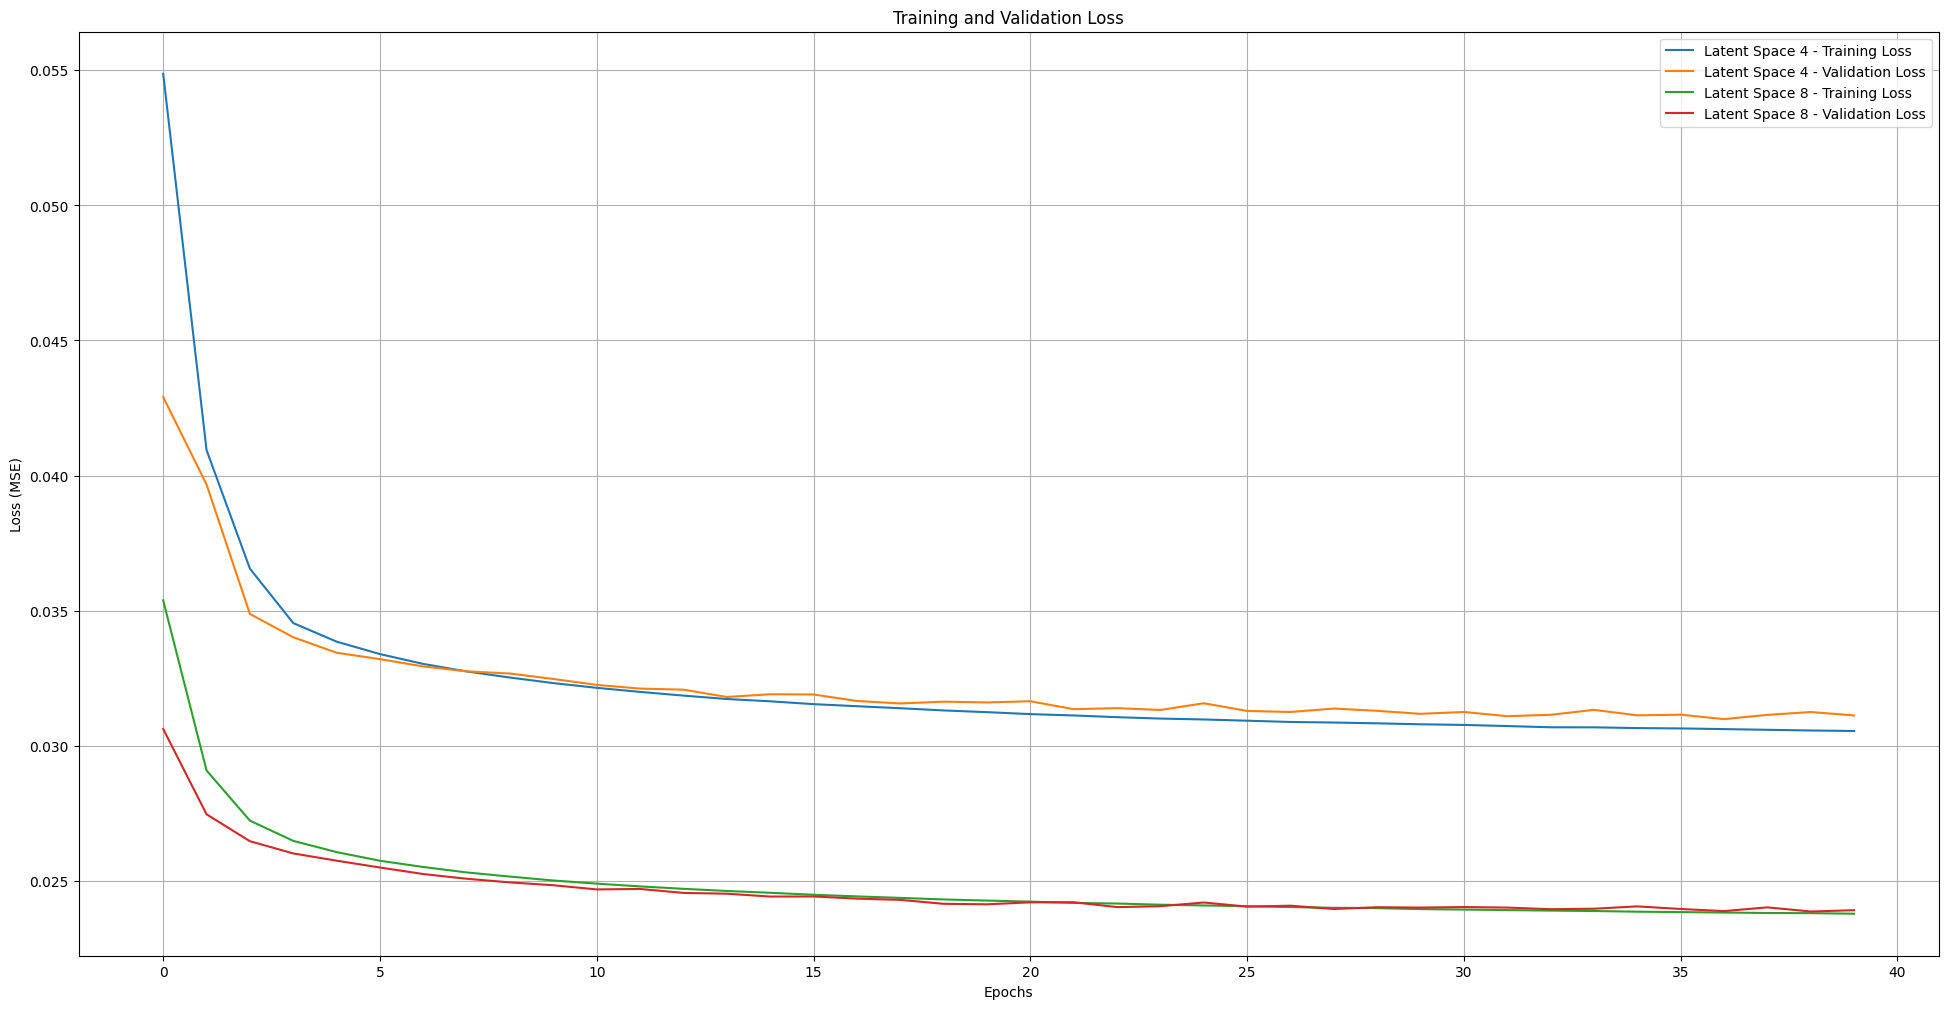

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))
plt.title("Training and Validation Loss")
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")

def plot_training_history(history, label):

    plt.plot(history.history['loss'], label=f"{label} - Training Loss")
    plt.plot(history.history['val_loss'], label=f"{label} - Validation Loss")


plot_training_history(autoencoder_latent_space_4_history, label="Latent Space 4")
plot_training_history(autoencoder_latent_space_8_history, label="Latent Space 8")

plt.legend()
plt.show()


As we can see, the latent space of size 8 preforms better than 4, this could show that maybe in order to represent the data with higher accuracy, we might need more than 4 neurons at the latent space.

##### 4-3-2 Implementing the MLP for classification

After training our autoencoders, we are now going to train a simple MLP with with one hidden layer (4 Neurons) to preform classification.

Since we have multiple classes (numbers 0 to 9) we need to first encode them with one-hot encoding, this has been done with the to_categorical() functions

In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Input

y_train_onehot = to_categorical(
    y_train, 
    num_classes=10
)
y_test_onehot = to_categorical(
    y_test, 
    num_classes=10
)

def build_classifier(
    encoder, 
    latent_dimension,
    extra_layer=True
):
    encoder.trainable = False
    
    input_layer = Input(
        shape=(latent_dimension,)
    )
    middle_layer = encoder(
        input_layer
    )

    if extra_layer:
        middle_layer = Dense(
            4, 
            activation="relu"
        )(middle_layer)
    
    output_layer = Dense(
        10, 
        activation="softmax"
    )(middle_layer)
    classifier = Model(
        input_layer, 
        output_layer
    )
    classifier.compile(
        loss="categorical_crossentropy", 
        optimizer="adam", 
        metrics=["accuracy"]
    )
    
    return classifier

Now we need to extract the encoding part of the auto encoder and call our function to create the deep belief network

In [8]:
encoder_latent_space_8 = Model(
    inputs=autoencoder_latent_space_8.input, 
    outputs=autoencoder_latent_space_8.get_layer('latent_layer').output
)
classifier_8 = build_classifier(
    encoder_latent_space_8, 
    latent_dimension=8
)


encoder_latent_space_4 = Model(
    inputs=autoencoder_latent_space_4.input,
    outputs=autoencoder_latent_space_4.get_layer('latent_layer').output
)
classifier_4_extra_layer = build_classifier(
    encoder_latent_space_4, 
    latent_dimension=4
)
classifier_4 = build_classifier(
    encoder_latent_space_4,
    latent_dimension=4,
    extra_layer=False
)

classifier_8_history = classifier_8.fit(
    x_train, 
    y_train_onehot, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, y_test_onehot)
)
classifier_4 = classifier_4.fit(
    x_train, 
    y_train_onehot, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, y_test_onehot)
)
classifier_4_extra_layer_history = classifier_4_extra_layer.fit(
    x_train, 
    y_train_onehot, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, y_test_onehot)
)

AttributeError: The layer sequential has never been called and thus has no defined input.